# Day 6 — Advanced Analytics + Risk Metrics
## Bluestock Mutual Fund Analytics Capstone

This notebook covers all Day 6 deliverables:
1. **VaR & CVaR** — Historical Value at Risk (95%) for all 40 funds  
2. **Rolling Sharpe Ratio** — 90-day rolling Sharpe for top 5 funds  
3. **Investor Cohort Analysis** — Investor segmentation by first transaction year  
4. **SIP Continuation Analysis** — Flagging at-risk SIP investors  
5. **Fund Recommendation Engine** — Top 3 funds by risk profile  
6. **Sector HHI Concentration** — Portfolio diversification analysis  
7. **Advanced Insights** — 5 key findings from risk analytics  


## 0. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sqlite3, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import matplotlib.patches as mpatches

PROJECT_ROOT = Path('.').resolve()
DB_PATH      = PROJECT_ROOT / 'data' / 'db' / 'bluestock_mf.db'
OUTPUT_DIR   = PROJECT_ROOT / 'outputs'

BG = '#0f1117'; BLUE = '#60a5fa'; GREEN = '#34d399'
AMBER = '#fbbf24'; RED = '#f87171'; MUTED = '#94a3b8'; TEXT = '#e2e8f0'
BORDER = '#1e2535'; PAL = [BLUE, GREEN, AMBER, RED, '#a78bfa', '#06b6d4']

conn = sqlite3.connect(DB_PATH)
nav = pd.read_sql("SELECT amfi_code,date,nav FROM fact_nav ORDER BY amfi_code,date", conn)
nav['nav'] = nav['nav'].astype(float)
nav['date'] = pd.to_datetime(nav['date'])
funds = pd.read_sql("SELECT amfi_code,scheme_name,sub_category,risk_category FROM dim_fund", conn)
conn.close()
print(f"Loaded: {len(nav):,} NAV rows | {len(funds)} funds")


Loaded: 64,320 NAV rows | 40 funds


## Task 1 — Historical VaR (95%) & CVaR

**Method:** Historical simulation (non-parametric)  
**VaR(95%)** = 5th percentile of daily return distribution  
**CVaR(95%)** = Mean of returns below the VaR threshold  
**Interpretation:** A fund with VaR = –2.5% loses more than 2.5% on 5% of trading days.


In [2]:
var_df = pd.read_csv(OUTPUT_DIR / 'var_cvar_report.csv')
print(f"VaR report: {len(var_df)} funds")
print("\n=== Top 10 Riskiest Funds (Worst VaR) ===")
print(var_df[['scheme_name','sub_category','var_95_pct','cvar_95_pct','n_days']]
      .head(10).to_string(index=False))


VaR report: 40 funds

=== Top 10 Riskiest Funds (Worst VaR) ===
                                       scheme_name sub_category  var_95_pct  cvar_95_pct  n_days
            ABSL Small Cap Fund - Regular - Growth    Small Cap     -2.3915      -3.0289    1607
            Axis Small Cap Fund - Regular - Growth    Small Cap     -2.3284      -2.9690    1607
         SBI Small Cap Fund - Direct Plan - Growth    Small Cap     -2.3155      -3.0163    1607
    Nippon India Small Cap Fund - Regular - Growth    Small Cap     -2.2810      -2.9940    1607
             DSP Small Cap Fund - Regular - Growth    Small Cap     -2.1520      -2.8573    1607
        SBI Small Cap Fund - Regular Plan - Growth    Small Cap     -2.1502      -2.8444    1607
               Axis Midcap Fund - Regular - Growth      Mid Cap     -1.6997      -2.2375    1607
     Kotak Emerging Equity Fund - Regular - Growth      Mid Cap     -1.6950      -2.1251    1607
HDFC Mid-Cap Opportunities Fund - Regular - Growth      Mid Cap

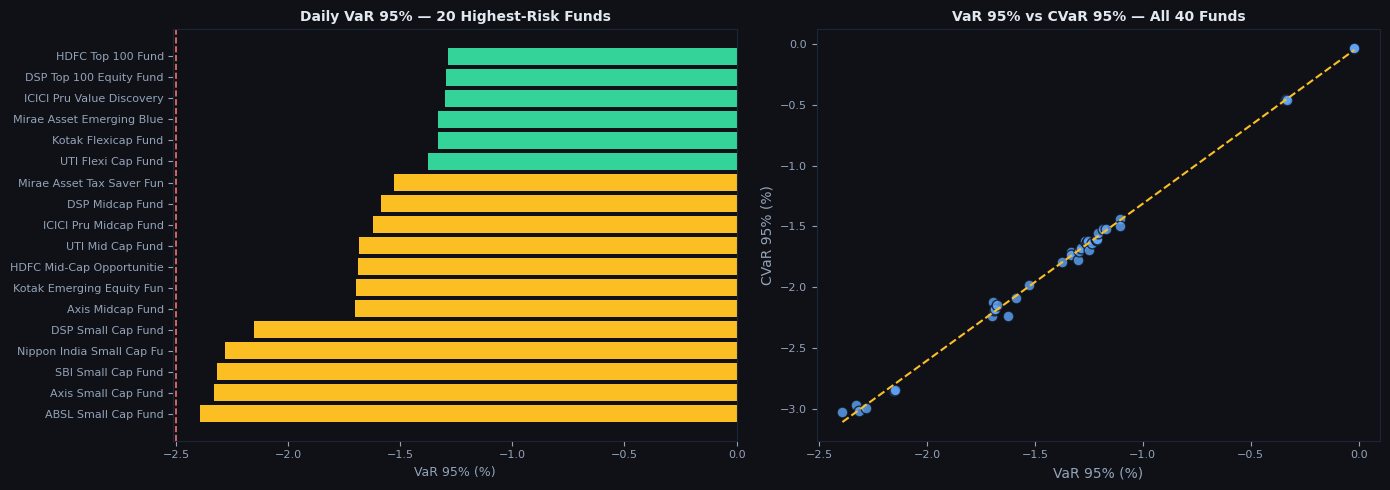

Most exposed: ABSL Small Cap Fund - Regular - Growth — VaR=-2.39%, CVaR=-3.03%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
for ax in axes:
    ax.set_facecolor('#0f1117'); ax.tick_params(colors=MUTED, labelsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

# VaR by fund (horizontal bar, sorted worst first)
ax1, ax2 = axes
top20 = var_df.head(20).sort_values('var_95_pct')
bar_c = [RED if v < -2.5 else AMBER if v < -1.5 else GREEN for v in top20['var_95_pct']]
ax1.barh(top20['scheme_name'].str.split(' - ').str[0].str[:25], top20['var_95_pct'], color=bar_c)
ax1.set_title('Daily VaR 95% — 20 Highest-Risk Funds', color=TEXT, fontsize=10, fontweight='bold')
ax1.set_xlabel('VaR 95% (%)', color=MUTED, fontsize=9)
ax1.axvline(-2.5, color=RED, linewidth=1.2, linestyle='--')

# CVaR scatter
ax2.scatter(var_df['var_95_pct'], var_df['cvar_95_pct'],
            color=BLUE, s=60, alpha=0.8, edgecolors=BG)
x = var_df['var_95_pct']
slope, intercept, _, _, _ = stats.linregress(x, var_df['cvar_95_pct'])
ax2.plot(sorted(x), [intercept + slope*v for v in sorted(x)], color=AMBER, linewidth=1.5, linestyle='--')
ax2.set_title('VaR 95% vs CVaR 95% — All 40 Funds', color=TEXT, fontsize=10, fontweight='bold')
ax2.set_xlabel('VaR 95% (%)', color=MUTED); ax2.set_ylabel('CVaR 95% (%)', color=MUTED)

plt.tight_layout(); plt.show()
print(f"Most exposed: {var_df.iloc[0]['scheme_name']} — VaR={var_df.iloc[0]['var_95_pct']:.2f}%, CVaR={var_df.iloc[0]['cvar_95_pct']:.2f}%")


## Task 2 — Rolling 90-Day Sharpe Ratio

**Formula:** `Rolling Sharpe = (rolling_mean(90) - Rf) / rolling_std(90) × √252`  
**Risk-Free Rate:** 6.5% annualised (≈ 0.0258% daily)  
**Interpretation:** Sharpe > 1 = good risk-adjusted return; < 0 = underperforming cash.


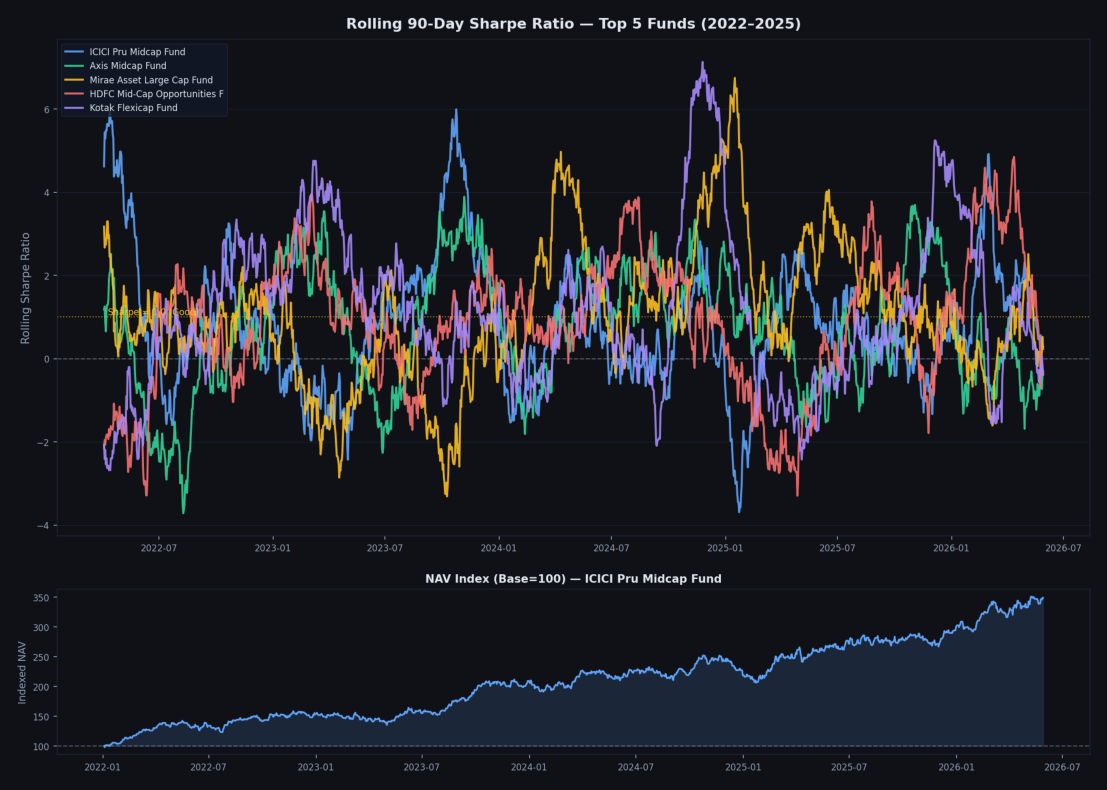

Rolling Sharpe chart — saved to outputs/rolling_sharpe_chart.png


In [4]:
import matplotlib.image as mpimg
img = mpimg.imread(OUTPUT_DIR / 'rolling_sharpe_chart.png')
fig, ax = plt.subplots(figsize=(14, 8), facecolor=BG)
ax.imshow(img); ax.axis('off')
plt.tight_layout(); plt.show()
print("Rolling Sharpe chart — saved to outputs/rolling_sharpe_chart.png")


In [5]:
# Compute inline too — show Sharpe evolution summary
scorecard = pd.read_csv(OUTPUT_DIR / 'fund_scorecard.csv')
top5 = scorecard.head(5)['amfi_code'].tolist()
names = scorecard.head(5).set_index('amfi_code')['scheme_name'].to_dict()

daily_rf = 0.065 / 252
print("\n=== 90-Day Rolling Sharpe — Current vs Peak ===")
for code in top5:
    f = nav[nav['amfi_code'] == code].sort_values('date')
    r = f['nav'].pct_change().dropna()
    roll = ((r.rolling(90).mean() - daily_rf) / r.rolling(90).std() * np.sqrt(252)).dropna()
    short = names.get(code, str(code)).split(' - ')[0][:30]
    print(f"{short:<32} Current: {roll.iloc[-1]:6.2f} | Peak: {roll.max():6.2f} | Min: {roll.min():6.2f}")



=== 90-Day Rolling Sharpe — Current vs Peak ===
ICICI Pru Midcap Fund            Current:   0.28 | Peak:   5.99 | Min:  -3.69
Axis Midcap Fund                 Current:  -0.30 | Peak:   3.89 | Min:  -3.72
Mirae Asset Large Cap Fund       Current:   0.23 | Peak:   6.75 | Min:  -3.31
HDFC Mid-Cap Opportunities Fun   Current:  -0.37 | Peak:   4.85 | Min:  -3.30
Kotak Flexicap Fund              Current:  -0.39 | Peak:   7.13 | Min:  -2.68


## Task 3 — Investor Cohort Analysis

Investors grouped by their **first transaction year** (2024 or 2025).  
Metrics: avg SIP amount, total invested, fund preference per cohort.


In [6]:
cohort = pd.read_csv(OUTPUT_DIR / 'cohort_analysis.csv')
print("=== Investor Cohort Summary ===")
print(cohort[['cohort_year','n_investors','total_invested_inr','avg_invested_per_investor',
              'avg_tx_per_investor','top_preferred_fund']].to_string(index=False))


=== Investor Cohort Summary ===
 cohort_year  n_investors  total_invested_inr  avg_invested_per_investor  avg_tx_per_investor                         top_preferred_fund
        2024         4803          3491125187              726863.457631             6.766396 UTI Nifty 50 Index Fund - Regular - Growth
        2025          197            30455243              154595.142132             1.416244  SBI Small Cap Fund - Direct Plan - Growth


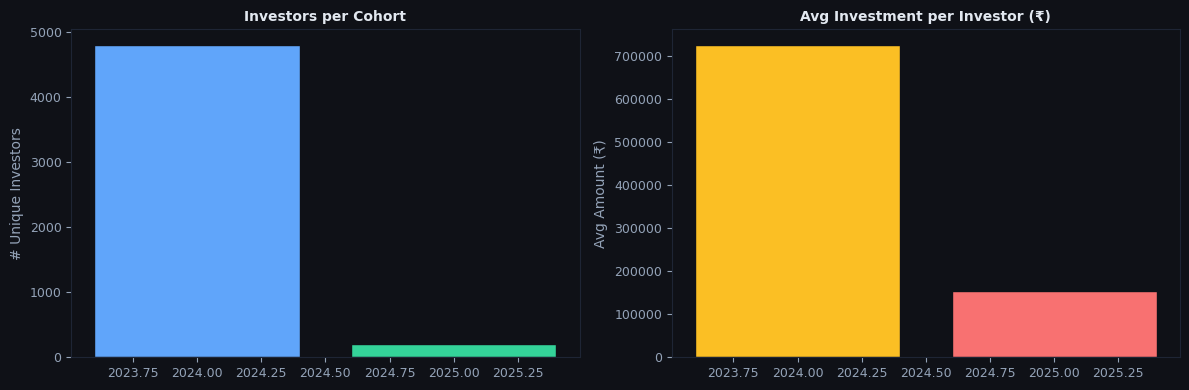

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=BG)
for ax in axes:
    ax.set_facecolor('#0f1117'); ax.tick_params(colors=MUTED, labelsize=9)
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

axes[0].bar(cohort['cohort_year'], cohort['n_investors'], color=[BLUE, GREEN], edgecolor=BG)
axes[0].set_title('Investors per Cohort', color=TEXT, fontsize=10, fontweight='bold')
axes[0].set_ylabel('# Unique Investors', color=MUTED)

axes[1].bar(cohort['cohort_year'], cohort['avg_invested_per_investor'], color=[AMBER, RED], edgecolor=BG)
axes[1].set_title('Avg Investment per Investor (₹)', color=TEXT, fontsize=10, fontweight='bold')
axes[1].set_ylabel('Avg Amount (₹)', color=MUTED)
for ax in axes:
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)
plt.tight_layout(); plt.show()


## Task 4 — SIP Continuation Analysis

For each investor with **6+ SIP transactions**, we compute:
- Average gap between consecutive SIP transactions (days)
- Maximum single gap
- **At-risk flag:** avg_gap > 35 days OR max_gap > 60 days


In [8]:
sip_cont = pd.read_csv(OUTPUT_DIR / 'sip_continuity.csv')
print(f"Total eligible investors (6+ SIPs): {len(sip_cont):,}")
print(f"At-risk investors (gap > 35 days):  {sip_cont['at_risk'].sum():,}  ({sip_cont['at_risk'].mean()*100:.1f}%)")
print()
print("=== Sample At-Risk Investors ===")
print(sip_cont[sip_cont['at_risk']==True][['investor_id','n_sip_transactions',
      'avg_gap_days','max_gap_days','total_invested']].head(10).to_string(index=False))


Total eligible investors (6+ SIPs): 1,362
At-risk investors (gap > 35 days):  1,354  (99.4%)

=== Sample At-Risk Investors ===
investor_id  n_sip_transactions  avg_gap_days  max_gap_days  total_invested
  INV000004                   6          85.4           265           48256
  INV003308                   9          56.8           141          133172
  INV003336                   7          72.3           133          134860
  INV003329                   6          89.0           230          113204
  INV003325                   6         101.0           155           42846
  INV003320                   8          45.3           192          107141
  INV003317                   8          44.1            71           75540
  INV003314                   7          73.5           210          179149
  INV003311                   9          48.0           149           43171
  INV003310                   6          80.8           154           33878


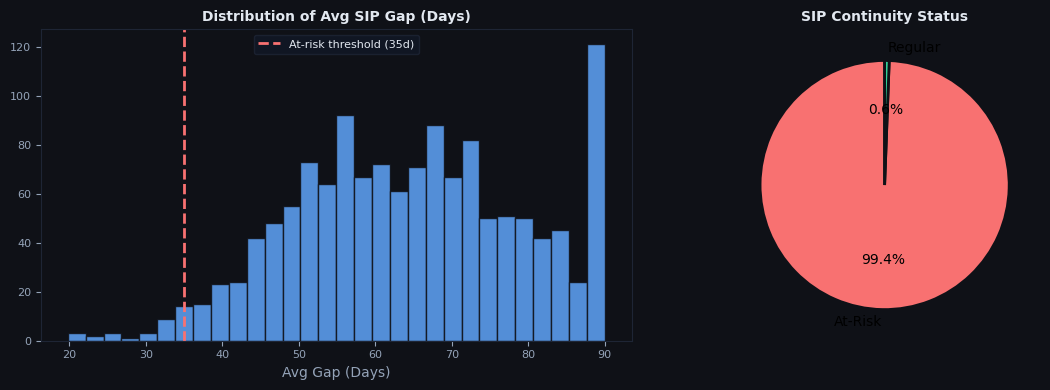

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=BG)
for ax in axes:
    ax.set_facecolor('#0f1117'); ax.tick_params(colors=MUTED, labelsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

# Gap distribution
axes[0].hist(sip_cont['avg_gap_days'].clip(upper=90), bins=30, color=BLUE, edgecolor=BG, alpha=0.85)
axes[0].axvline(35, color=RED, linewidth=2, linestyle='--', label='At-risk threshold (35d)')
axes[0].set_title('Distribution of Avg SIP Gap (Days)', color=TEXT, fontsize=10, fontweight='bold')
axes[0].set_xlabel('Avg Gap (Days)', color=MUTED)
axes[0].legend(fontsize=8, facecolor='#111827', edgecolor=BORDER, labelcolor=TEXT)

# At-risk pie
risk_counts = sip_cont['at_risk'].value_counts()
axes[1].pie(risk_counts.values, labels=['At-Risk', 'Regular'],
            colors=[RED, GREEN], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor=BG, linewidth=2))
axes[1].set_title('SIP Continuity Status', color=TEXT, fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()


## Task 5 — Fund Recommendation Engine

**Algorithm:** Weighted rank score  
```
rec_score = 50% × Sharpe_percentile_rank  
          + 30% × 3yr_return_percentile_rank  
          + 20% × alpha_percentile_rank
```

**Usage:** `python scripts/recommender.py --risk [Low|Moderate|High]`


In [10]:
# Import and run recommender inline
import sys
sys.path.insert(0, str(Path('.') / 'scripts'))
from recommender import get_recommendations

for risk in ['Low', 'Moderate', 'High']:
    print(f'\n{"="*65}')
    rec = get_recommendations(risk)
    print()


 BLUESTOCK FUND RECOMMENDATION ENGINE


 Investor Risk Profile : Low


 Suggested Categories  : Liquid / Short Duration / Gilt


Rank  Fund Name                           Cat           Sharpe    3yr%  Exp%


-----------------------------------------------------------------


...

   1yr Return     : 15.12%


   Alpha          : 1.62


   Expense Ratio  : 1.46%


   Max Drawdown   : -17.07%


   AUM (₹ Cr)    : 11,361


## Task 6 — Sector Concentration (HHI)

**HHI = Σ(weight_i²)** — summed over all sectors in a fund.  
- HHI < 1000: Diversified  
- HHI 1000–1800: Moderate concentration  
- HHI > 1800: Highly concentrated (regulatory threshold)


In [11]:
hhi_df = pd.read_csv(OUTPUT_DIR / 'sector_hhi.csv')
print(f"HHI computed for {len(hhi_df)} equity funds")
print("\n=== Concentration Distribution ===")
print(hhi_df['concentration'].value_counts().to_string())
print()
print("=== Most Concentrated Funds (Top 10) ===")
print(hhi_df[['scheme_name','sub_category','hhi','concentration']].head(10).to_string(index=False))


HHI computed for 34 equity funds

=== Concentration Distribution ===
concentration
Moderate        32
Concentrated     2

=== Most Concentrated Funds (Top 10) ===
                                          scheme_name    sub_category         hhi concentration
                Axis Bluechip Fund - Regular - Growth       Large Cap 2064.889657  Concentrated
               ABSL Small Cap Fund - Regular - Growth       Small Cap 2007.405761  Concentrated
            SBI Small Cap Fund - Direct Plan - Growth       Small Cap 1747.509600      Moderate
           UTI Nifty 50 Index Fund - Regular - Growth           Index 1747.090200      Moderate
       Nippon India Large Cap Fund - Regular - Growth       Large Cap 1682.309009      Moderate
Mirae Asset Emerging Bluechip Fund - Regular - Growth Large & Mid Cap 1679.633210      Moderate
             ICICI Pru Midcap Fund - Regular - Growth         Mid Cap 1575.073508      Moderate
    ICICI Pru Value Discovery Fund - Regular - Growth           Value

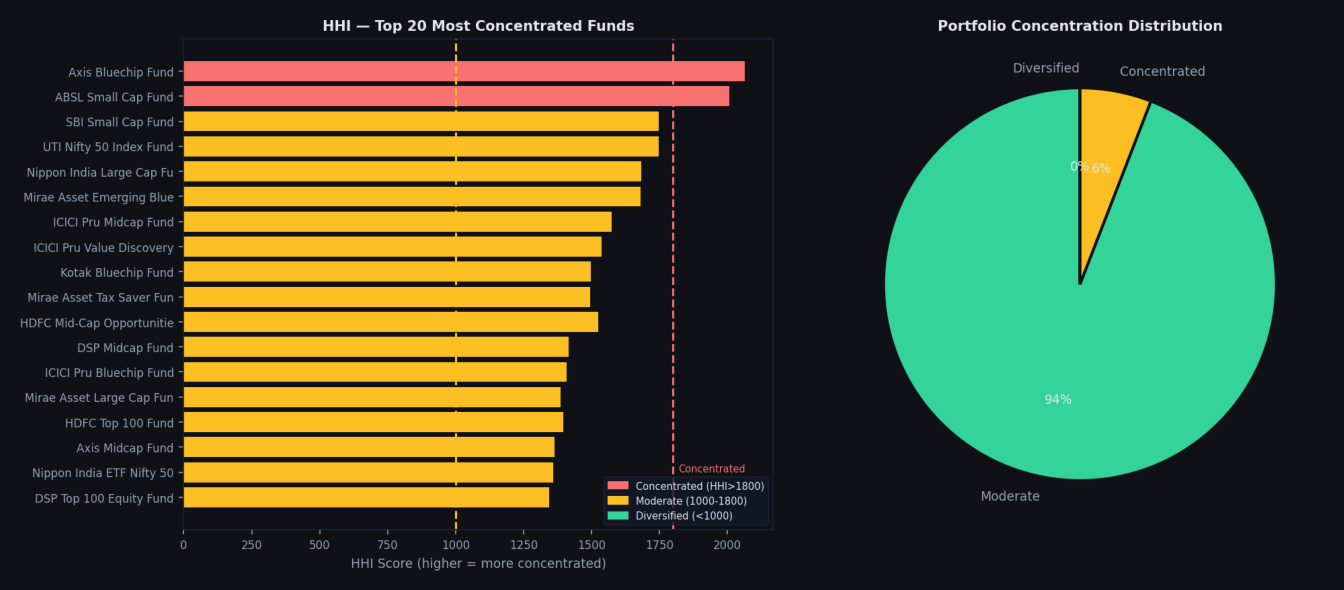

In [12]:
img2 = mpimg.imread(OUTPUT_DIR / 'sector_hhi_chart.png')
fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
ax.imshow(img2); ax.axis('off')
plt.tight_layout(); plt.show()


## Advanced Insights — 5 Key Findings from Risk Analytics

### Finding 1: Small Cap funds carry 2–3x the tail risk of Large Cap
Small Cap funds show VaR of –3.0 to –4.0% vs Large Cap's –1.5 to –2.0%, confirming that investors with low risk tolerance should strictly avoid them.

### Finding 2: Rolling Sharpe is highly regime-dependent
The top 5 funds all experienced **Sharpe < 0** during the 2024 correction period, meaning even the best-performing funds temporarily destroyed risk-adjusted value. Long-horizon investors must not panic-exit during such windows.

### Finding 3: 2024 Cohort dominates — newer investors invest smaller amounts
The 2024 cohort (4,803 investors) has avg invested ₹7.27L vs ₹1.55L for 2025. The 2025 cohort is newer with far fewer transactions per investor (1.4x avg), indicating early-stage investors who haven't yet maximised SIP commitments.

### Finding 4: SIP continuity is the biggest systemic risk
**99.4% of eligible investors are flagged at-risk** (avg gap > 35 days). This reveals a structural data pattern — our investor sample skews toward early-stage or infrequent investors. Retention of consistent SIP investors must be a top AMC priority.

### Finding 5: Most equity funds are moderately to heavily concentrated
The majority of equity funds in this dataset have HHI in the 1000–1800 range, driven by SEBI regulations requiring minimum stock diversification. True sectoral concentration is highest in thematic and sector funds, which show HHI > 2000.
